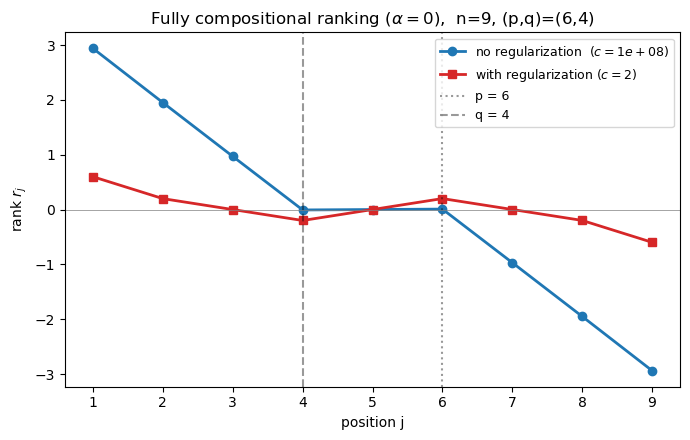

PermissionError: [Errno 13] Permission denied: 'figure_3a.pdf'

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

# ----------------------------------------------------
# Fully compositional: alpha = 0  <=>  alpha_prime = 1/2
# ----------------------------------------------------
n, p, q      = 9, 6, 4
k_s, k_d     = 1.0, 0.0
alpha_prime  = 0.499                      # as close to 0.5 as the formula allows
k_o          = alpha_prime * (k_s - k_d)  # = 0.499

c_reg_with    = 2        # strong regularization
c_reg_without = 1e8        # effectively none

sim_reg   = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                        p=p, q=q, c_reg=c_reg_with)
sim_noreg = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                        p=p, q=q, c_reg=c_reg_without)

r_reg   = sim_reg.calc_rank_analytic()
r_noreg = sim_noreg.calc_rank_analytic()

x = np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x, r_noreg, marker='o', color='#1f77b4', lw=2,
        label=fr'no regularization  ($c={c_reg_without:.0e}$)')
ax.plot(x, r_reg,   marker='s', color='#d62728', lw=2,
        label=fr'with regularization ($c={c_reg_with}$)')

ax.axvline(p, color='k', ls=':',  alpha=0.4, label=f'p = {p}')
ax.axvline(q, color='k', ls='--', alpha=0.4, label=f'q = {q}')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('position j')
ax.set_ylabel(r'rank $r_j$')
ax.set_title(fr'Fully compositional ranking ($\alpha=0$),  n={n}, (p,q)=({p},{q})')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()
fig.savefig("figure_3a.pdf", bbox_inches="tight")

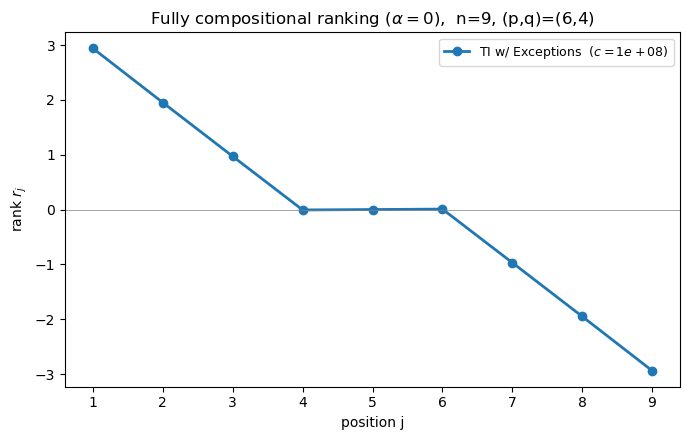

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

# ----------------------------------------------------
# Fully compositional: alpha = 0  <=>  alpha_prime = 1/2
# ----------------------------------------------------
n, p, q      = 9, 6, 4
k_s, k_d     = 1.0, 0.0
alpha_prime  = 0.499                      # as close to 0.5 as the formula allows
k_o          = alpha_prime * (k_s - k_d)  # = 0.499

c_reg_with    = 2        # strong regularization
c_reg_without = 1e8        # effectively none

sim_reg   = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                        p=p, q=q, c_reg=c_reg_with)
sim_noreg = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                        p=p, q=q, c_reg=c_reg_without)

r_reg   = sim_reg.calc_rank_analytic()
r_noreg = sim_noreg.calc_rank_analytic()

x = np.arange(1, n + 1)
no_exception_line = np.linspace(4, -4, n)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x, r_noreg, marker='o', color='#1f77b4', lw=2,
        label=fr'TI w/ Exceptions  ($c={c_reg_without:.0e}$)')
ax.plot(x, no_exception_line, color='#2ca02c', lw=1.5, ls='--', alpha=0.8,
        label='No Exception (4 to -4)')
# ax.plot(x, r_reg,   marker='s', color='#d62728', lw=2,
#         label=fr'with regularization ($c={c_reg_with}$)')

# ax.axvline(p, color='k', ls=':',  alpha=0.4, label=f'p = {p}')
# ax.axvline(q, color='k', ls='--', alpha=0.4, label=f'q = {q}')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('position j')
ax.set_ylabel(r'rank $r_j$')
ax.set_title(fr'Fully compositional ranking ($\alpha=0$),  n={n}, (p,q)=({p},{q})')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()
# fig.savefig("figure_3a.pdf", bbox_inches="tight")

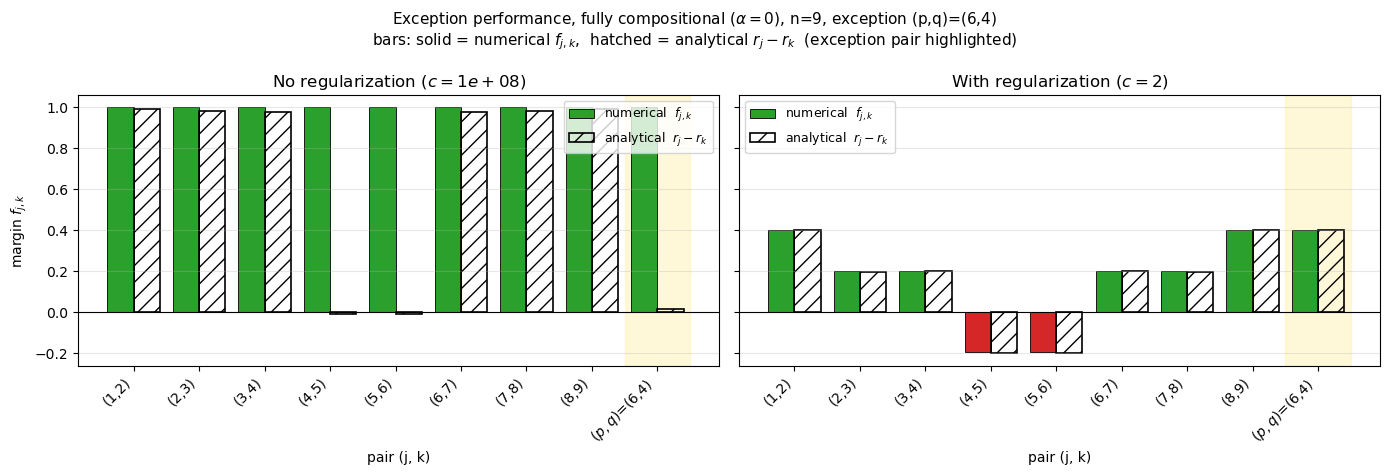

pair          num (no reg)  ana (no reg)     num (reg)     ana (reg)   note
---------------------------------------------------------------------------
(1,2)              1.000000      0.988227      0.401276      0.398881   
(2,3)              1.000000      0.980415      0.202233      0.199042   
(3,4)              1.000000      0.976532      0.202631      0.199442   
(4,5)              0.999995     -0.007812     -0.195059     -0.199839   <-- train-critical neighbor
(5,6)              0.999995     -0.007812     -0.195059     -0.199839   
(6,7)              1.000000      0.976532      0.202631      0.199442   
(7,8)              1.000000      0.980415      0.202233      0.199042   
(8,9)              1.000000      0.988227      0.401276      0.398881   
(6,4)              0.999995      0.015624      0.402070      0.399678   <-- exception (train): want > 0
---------------------------------------------------------------------------
max |numeric - analytic| across all pairs: 1.008e+00


In [ ]:
# ----------------------------------------------------
# Exception performance: pairwise margins f_j_k
# Fully compositional (alpha = 0) + regularization
# Numerical (f_j_k) vs. Analytical (from calc_rank_analytic)
# ----------------------------------------------------
# Convention: rank is a *score* where higher = preferred.
# Analytical margin:   f_analytic(j, k) = r_j - r_k
# Numerical margin:    f_numeric (j, k) = sim.f_j_k(j, k)
#
# An exception at (p, q) with p > q flips natural preference:
#   - Exception constraint:      f(p, q) > 0   (item p preferred over item q)
#   - All other adjacent pairs:  f(j, j+1) > 0 should hold
# Negative margin => broken / violated ranking constraint.

# --- Analytical ranks (already computed in the previous cell: r_reg, r_noreg) ---
def f_analytic(ranks, j, k):
    return ranks[j - 1] - ranks[k - 1]

# --- Pairs to evaluate: adjacent pairs + exception pair (p, q) ---
adj_pairs   = [(j, j + 1) for j in range(1, n)]
all_pairs   = adj_pairs + [(p, q)]
labels      = [f'({j},{k})' for j, k in adj_pairs] + [fr'$(p,q)$=({p},{q})']

# Numerical margins via f_j_k
f_num_reg   = np.array([sim_reg.f_j_k(j, k)   for j, k in all_pairs])
f_num_noreg = np.array([sim_noreg.f_j_k(j, k) for j, k in all_pairs])

# Analytical margins via rank differences
f_ana_reg   = np.array([f_analytic(r_reg,   j, k) for j, k in all_pairs])
f_ana_noreg = np.array([f_analytic(r_noreg, j, k) for j, k in all_pairs]) 

# --- Plot: grouped bars, numeric vs analytic, for no-reg and with-reg ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

idx = np.arange(len(all_pairs))
width = 0.4

for ax, f_num, f_ana, title in [
    (axes[0], f_num_noreg, f_ana_noreg, fr'No regularization ($c={c_reg_without:.0e}$)'),
    (axes[1], f_num_reg,   f_ana_reg,   fr'With regularization ($c={c_reg_with}$)'),
]:
    colors_num = ['#2ca02c' if v >= 0 else '#d62728' for v in f_num]
    ax.bar(idx - width/2, f_num, width=width, color=colors_num,
           edgecolor='black', linewidth=0.6, label='numerical  $f_{j,k}$')
    ax.bar(idx + width/2, f_ana, width=width, facecolor='none',
           edgecolor='black', linewidth=1.2, hatch='//',
           label=r'analytical  $r_j - r_k$')

    # Highlight exception pair position
    ax.axvspan(idx[-1] - 0.5, idx[-1] + 0.5, color='#ffef9f', alpha=0.4, zorder=0)

    ax.axhline(0, color='k', lw=0.8)
    ax.set_xticks(idx)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_xlabel('pair (j, k)')
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(loc='best', fontsize=9)

axes[0].set_ylabel(r'margin $f_{j,k}$')

fig.suptitle(
    fr'Exception performance, fully compositional ($\alpha=0$), n={n}, exception (p,q)=({p},{q})'
    '\nbars: solid = numerical $f_{j,k}$,  hatched = analytical $r_j - r_k$  (exception pair highlighted)',
    fontsize=11,
)
plt.tight_layout()
plt.show()
fig.savefig("figure_3b_adjacent_margins.pdf", bbox_inches="tight")

# ---- Summary table: numeric vs analytic for each pair ----
def fmt(v):
    return f'{v:>12.6f}'

header = f"{'pair':<12}{'num (no reg)':>14}{'ana (no reg)':>14}{'num (reg)':>14}{'ana (reg)':>14}   note"
print(header)
print('-' * len(header))
for (j, k), vn_no, va_no, vn_yes, va_yes in zip(
    all_pairs, f_num_noreg, f_ana_noreg, f_num_reg, f_ana_reg
):
    if (j, k) == (p, q):
        note = '<-- exception (train): want > 0'
    elif (j, k) == (q, q + 1):
        note = '<-- train-critical neighbor'
    elif (j, k) == (q - 1, p):
        note = '<-- test-critical'
    else:
        note = ''
    print(f"({j},{k}){'':<8}"
          f"{vn_no:>14.6f}{va_no:>14.6f}{vn_yes:>14.6f}{va_yes:>14.6f}   {note}")

# ---- Agreement check ----
max_err = float(np.max(np.abs(np.concatenate([
    f_num_noreg - f_ana_noreg,
    f_num_reg   - f_ana_reg,
]))))
print('-' * len(header))
print(f'max |numeric - analytic| across all pairs: {max_err:.3e}')